# Étape 1 : Importation des bibliothèques nécessaires

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Définir le chemin vers le dossier contenant les données brutes
DATA_DIR = "../../data/raw" # À ajuster selon l'emplacement exact de votre notebook

# Étape 2 : Exploration séquentielle des fichiers CSV

In [2]:
def inspecter_csv(nom_fichier):
    chemin = os.path.join(DATA_DIR, nom_fichier)
    print("="*60)
    print(f"ANALYSE DU FICHIER : {nom_fichier}")
    print("="*60)
    
    try:
        # Lecture des premières lignes pour aperçu et détection automatique des séparateurs
        # Souvent, les données françaises utilisent le point-virgule (;)
        df_preview = pd.read_csv(chemin, nrows=5)
        
        # Si une seule colonne est détectée, on réessaye avec un point-virgule
        sep = ';' if df_preview.shape[1] == 1 else ','
        
        # Chargement complet (ou partiel si le fichier est gigantesque)
        df = pd.read_csv(chemin, sep=sep, low_memory=False)
        
        print(f"-> Dimensions : {df.shape[0]} lignes, {df.shape[1]} colonnes\n")
        print("-> Informations générales :")
        df.info()
        
        print("\n-> Aperçu des 3 premières lignes :")
        display(df.head(3))
        
        print("\n-> Taux de valeurs manquantes (%) :")
        print((df.isnull().sum() / len(df) * 100).round(2).to_string())
        
        return df
    except Exception as e:
        print(f"Erreur lors de la lecture de {nom_fichier} : {e}")
        return None

# Liste de vos fichiers CSV à charger séquentiellement
fichiers_csv = [
    "flux_nouveaux_emprunts.csv",
    "foyers_fiscaux.csv",
    "indice_reference_loyers.csv",
    "loyers.csv",
    "parc_immobilier.csv",
    "taux_endettement.csv",
    "taux_interet.csv",
    "transactions_sample.csv"
]

# Dictionnaire pour stocker les DataFrames si vous avez assez de RAM
dataframes = {}

for fichier in fichiers_csv:
    df_temp = inspecter_csv(fichier)
    if df_temp is not None:
        dataframes[fichier.split('.')[0]] = df_temp

ANALYSE DU FICHIER : flux_nouveaux_emprunts.csv
-> Dimensions : 170 lignes, 2 colonnes

-> Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   date         170 non-null    str  
 1   emprunts_M€  170 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.8 KB

-> Aperçu des 3 premières lignes :


,date,emprunts_M€
0,2024-07,16442
1,2024-06,13017
2,2024-05,10709



-> Taux de valeurs manquantes (%) :
date           0.0
emprunts_M€    0.0
ANALYSE DU FICHIER : foyers_fiscaux.csv
-> Dimensions : 315542 lignes, 15 colonnes

-> Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 315542 entries, 0 to 315541
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   date                 315542 non-null  int64  
 1   departement          315542 non-null  str    
 2   id_ville             315542 non-null  int64  
 3   ville                315542 non-null  str    
 4   n_foyers_fiscaux     315058 non-null  float64
 5   revenu_fiscal_moyen  314721 non-null  float64
 6   montant_impot_moyen  314712 non-null  float64
 7   n_foyers_0k_10k      51166 non-null   float64
 8   n_foyers_10k_12k     49356 non-null   float64
 9   n_foyers_12k_15k     51164 non-null   float64
 10  n_foyers_15k_20k     51167 non-null   float64
 11  n_foyers_20k_30k     51167 non-null   float64

,date,departement,id_ville,ville,n_foyers_fiscaux,revenu_fiscal_moyen,montant_impot_moyen,n_foyers_0k_10k,n_foyers_10k_12k,n_foyers_12k_15k,n_foyers_15k_20k,n_foyers_20k_30k,n_foyers_30k_50k,n_foyers_50k_100k,n_foyers_100k_plus
0,2022,01,1,L'Abergement-Clémenciat,466.0,35291.10,1718.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,01,2,L'Abergement-de-Varey,143.0,34788.93,1728.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,01,4,Ambérieu-en-Bugey,9276.0,26612.43,1251.87,1846.0,450.0,705.0,1630.0,1971.0,1668.0,894.0,112.0



-> Taux de valeurs manquantes (%) :
date                    0.00
departement             0.00
id_ville                0.00
ville                   0.00
n_foyers_fiscaux        0.15
revenu_fiscal_moyen     0.26
montant_impot_moyen     0.26
n_foyers_0k_10k        83.78
n_foyers_10k_12k       84.36
n_foyers_12k_15k       83.79
n_foyers_15k_20k       83.78
n_foyers_20k_30k       83.78
n_foyers_30k_50k       83.78
n_foyers_50k_100k      85.10
n_foyers_100k_plus     85.66
ANALYSE DU FICHIER : indice_reference_loyers.csv
-> Dimensions : 87 lignes, 2 colonnes

-> Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   quarter  87 non-null     str    
 1   IRL      87 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.5 KB

-> Aperçu des 3 premières lignes :


...


-> Taux de valeurs manquantes (%) :
date                0.0
taux_endettement    0.0
ANALYSE DU FICHIER : taux_interet.csv
-> Dimensions : 116 lignes, 2 colonnes

-> Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    116 non-null    str    
 1   taux    116 non-null    float64
dtypes: float64(1), str(1)
memory usage: 1.9 KB

-> Aperçu des 3 premières lignes :


,date,taux
0,2024-07,3.64
1,2024-06,3.70
2,2024-05,3.83



-> Taux de valeurs manquantes (%) :
date    0.0
taux    0.0
ANALYSE DU FICHIER : transactions_sample.csv
-> Dimensions : 100 lignes, 20 colonnes

-> Informations générales :
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_transaction              100 non-null    int64  
 1   date_transaction            100 non-null    str    
 2   prix                        100 non-null    float64
 3   departement                 100 non-null    int64  
 4   id_ville                    100 non-null    int64  
 5   ville                       100 non-null    str    
 6   code_postal                 100 non-null    int64  
 7   adresse                     100 non-null    str    
 8   type_batiment               100 non-null    str    
 9   vefa                        100 non-null    bool   
 10  n_pieces                    100 non-null   

,id_transaction,date_transaction,prix,departement,id_ville,ville,code_postal,adresse,type_batiment,vefa,n_pieces,surface_habitable,id_parcelle_cadastre,latitude,longitude,surface_dependances,surface_locaux_industriels,surface_terrains_agricoles,surface_terrains_sols,surface_terrains_nature
0,10160888,2015-07-22,222500.0,63,247,MUROL,63790,5148 COMBE,Maison,False,4,123,63247000ZO0165,45.572973,2.949976,{},{},{},{2387},{}
1,10319766,2024-06-18,218640.0,73,15,LES ALLUES,73550,45 RUE DU GRAND COEUR,Appartement,False,1,23,73015000AB0347,45.398740,6.567602,{0},{},{},{},{}
2,11545562,2020-07-23,254950.0,77,316,MORET-LOING-ET-ORVANNE,77250,1 RUE DE LA CROIX BLANCHE,Maison,False,6,124,773161700B0305,48.333762,2.780830,{},{},{},{815},{}



-> Taux de valeurs manquantes (%) :
id_transaction                0.0
date_transaction              0.0
prix                          0.0
departement                   0.0
id_ville                      0.0
ville                         0.0
code_postal                   0.0
adresse                       0.0
type_batiment                 0.0
vefa                          0.0
n_pieces                      0.0
surface_habitable             0.0
id_parcelle_cadastre          0.0
latitude                      0.0
longitude                     0.0
surface_dependances           0.0
surface_locaux_industriels    0.0
surface_terrains_agricoles    0.0
surface_terrains_sols         0.0
surface_terrains_nature       0.0


# Étape 3 : Chargement du fichier .npz (transactions.npz)

In [3]:
chemin_npz = os.path.join(DATA_DIR, "transactions.npz")

print("="*60)
print("ANALYSE DU FICHIER NUMPY : transactions.npz")
print("="*60)

try:
    with np.load(chemin_npz, allow_pickle=True) as data:
        print(f"-> Fichiers contenus dans l'archive : {data.files}")
        for key in data.files:
            print(f"\nStructure de la clé '{key}':")
            print(f" - Type : {type(data[key])}")
            print(f" - Forme (Shape) : {data[key].shape}")
            # Si c'est un tableau de taille raisonnable, afficher un aperçu
            if len(data[key].shape) == 1:
                print(f" - Exemple de contenu : {data[key][:5]}")
            elif len(data[key].shape) == 2:
                print(f" - Exemple de contenu (ligne 0) : {data[key][0, :5]}")
except Exception as e:
    print(f"Erreur lors de la lecture du fichier NPZ : {e}")

ANALYSE DU FICHIER NUMPY : transactions.npz
-> Fichiers contenus dans l'archive : ['id_transaction', 'date_transaction', 'prix', 'departement', 'id_ville', 'ville', 'code_postal', 'adresse', 'type_batiment', 'vefa', 'n_pieces', 'surface_habitable', 'id_parcelle_cadastre', 'latitude', 'longitude', 'surface_dependances', 'surface_locaux_industriels', 'surface_terrains_agricoles', 'surface_terrains_sols', 'surface_terrains_nature']

Structure de la clé 'id_transaction':
 - Type : <class 'numpy.ndarray'>
 - Forme (Shape) : (9141573,)
 - Exemple de contenu : [141653 141970 139240 146016 145911]

Structure de la clé 'date_transaction':
 - Type : <class 'numpy.ndarray'>
 - Forme (Shape) : (9141573,)
 - Exemple de contenu : ['2014-01-02T00:00:00.000000000' '2014-01-02T00:00:00.000000000'
 '2014-01-02T00:00:00.000000000' '2014-01-02T00:00:00.000000000'
 '2014-01-03T00:00:00.000000000']

Structure de la clé 'prix':
 - Type : <class 'numpy.ndarray'>
 - Forme (Shape) : (9141573,)
 - Exemple de con

# Graphique 1 : Corrélation entre Taux d'intérêt et Volume des Emprunts

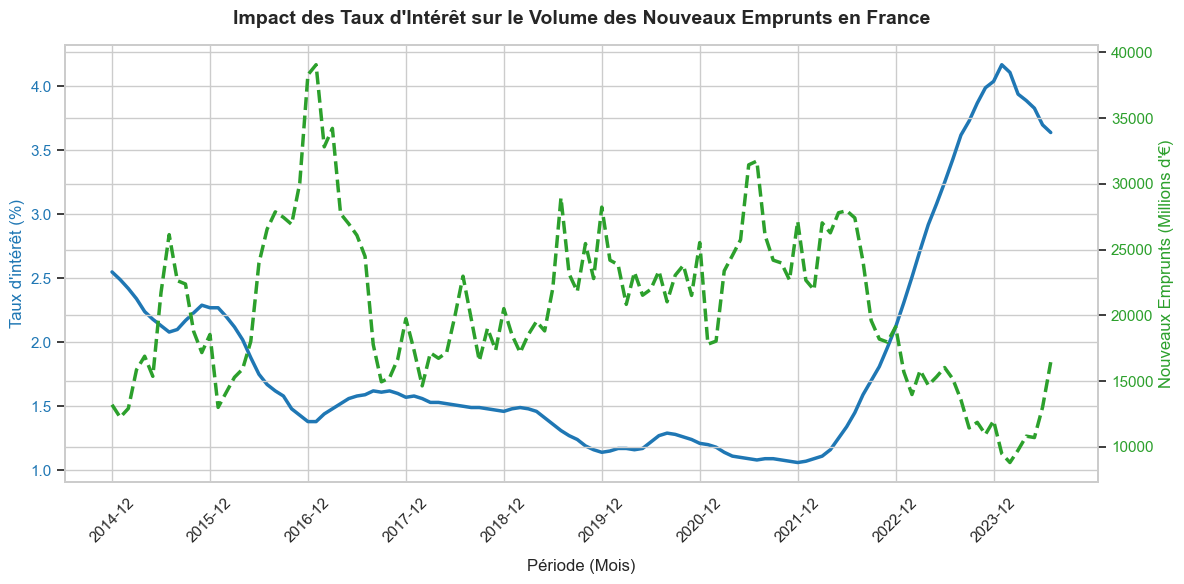

In [4]:

# Configuration du style des graphiques
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Chargement et fusion des données macro
df_taux = pd.read_csv(os.path.join(DATA_DIR, "taux_interet.csv"), sep=None, engine='python')
df_emprunts = pd.read_csv(os.path.join(DATA_DIR, "flux_nouveaux_emprunts.csv"), sep=None, engine='python')

# Fusion sur la clé 'date' (Format YYYY-MM)
df_macro = pd.merge(df_taux, df_emprunts, on='date').sort_values('date')

# Création du graphique avec un double axe Y
fig, ax1 = plt.subplots()

color = '#1f77b4'
ax1.set_xlabel('Période (Mois)', fontsize=12, labelpad=10)
ax1.set_ylabel('Taux d\'intérêt (%)', color=color, fontsize=12)
ax1.plot(df_macro['date'], df_macro['taux'], color=color, linewidth=2.5, label='Taux d\'intérêt')
ax1.tick_params(axis='y', labelcolor=color)

# Configuration de l'axe X pour ne pas surcharger les étiquettes
ax1.set_xticks(df_macro['date'][::12]) 
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()  
color = '#2ca02c'
ax2.set_ylabel('Nouveaux Emprunts (Millions d\'€)', color=color, fontsize=12)
ax2.plot(df_macro['date'], df_macro['emprunts_M€'], color=color, linewidth=2.5, linestyle='--', label='Volume Emprunts')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Impact des Taux d\'Intérêt sur le Volume des Nouveaux Emprunts en France', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

# Graphique 2 : Évolution de l'Indice de Référence des Loyers (IRL)

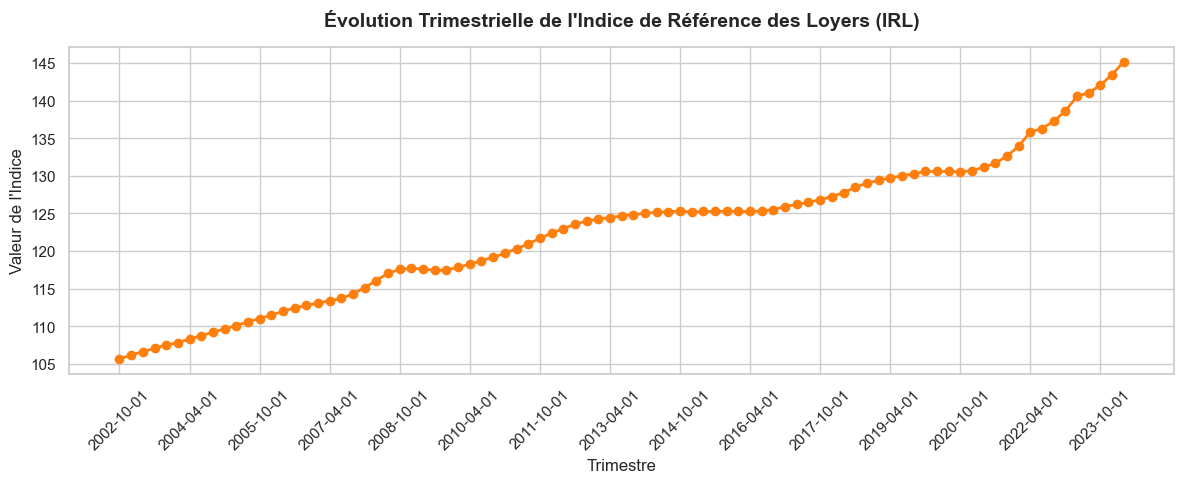

In [5]:
# 2. Évolution de l'IRL
df_irl = pd.read_csv(os.path.join(DATA_DIR, "indice_reference_loyers.csv"), sep=None, engine='python')
df_irl = df_irl.sort_values('quarter')

plt.figure(figsize=(12, 5))
plt.plot(df_irl['quarter'], df_irl['IRL'], color='#ff7f0e', marker='o', linewidth=2)
plt.title('Évolution Trimestrielle de l\'Indice de Référence des Loyers (IRL)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trimestre', fontsize=12)
plt.ylabel('Valeur de l\'Indice', fontsize=12)
plt.xticks(df_irl['quarter'][::6], rotation=45)
plt.tight_layout()
plt.show()

# Graphique 3 : Analyse des Prix des Transactions (Échantillon)

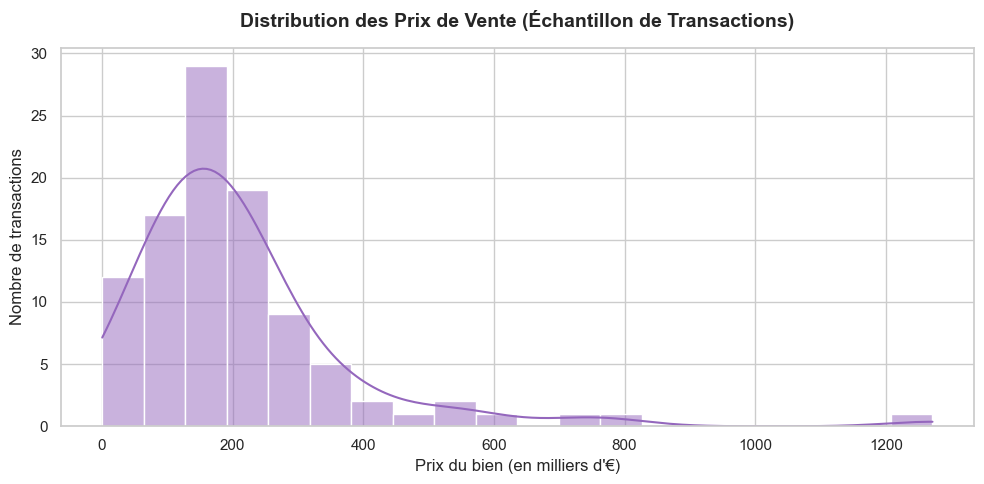

In [6]:
# 3. Distribution des prix de vente
df_trans_sample = pd.read_csv(os.path.join(DATA_DIR, "transactions_sample.csv"), sep=None, engine='python')

plt.figure(figsize=(10, 5))
sns.histplot(df_trans_sample['prix'] / 1000, bins=20, kde=True, color='#9467bd')
plt.title('Distribution des Prix de Vente (Échantillon de Transactions)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Prix du bien (en milliers d\'€)', fontsize=12)
plt.ylabel('Nombre de transactions', fontsize=12)
plt.tight_layout()
plt.show()

# Graphique 4 : La Vraie Distribution des Prix (Sur les 9 millions de ventes)

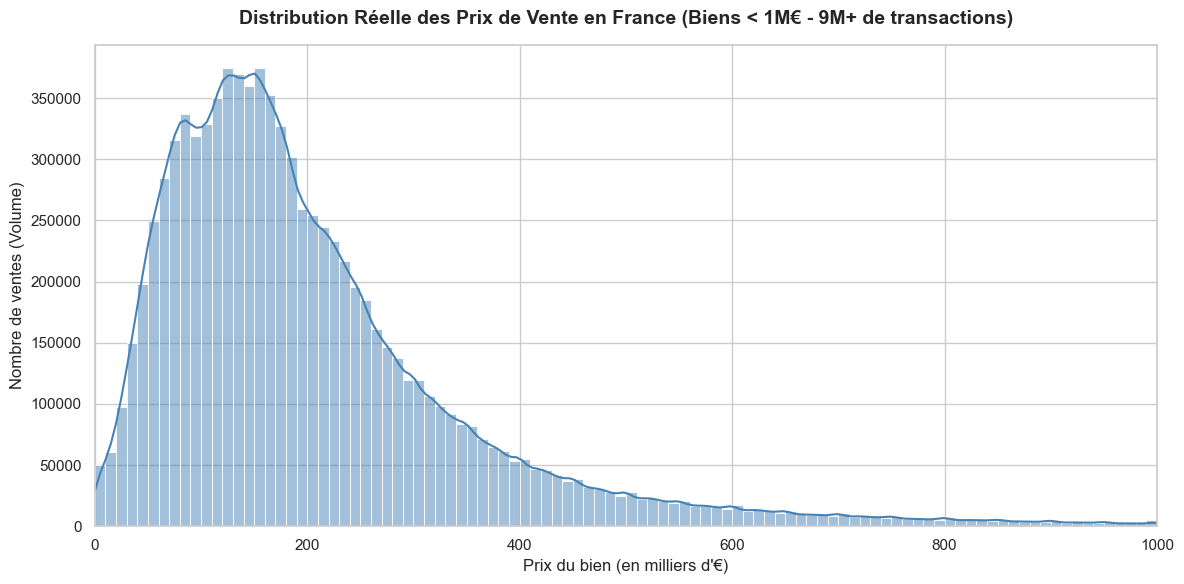

In [7]:
# 4. Distribution réelle sur la totalité des 9 millions de transactions
with np.load(os.path.join(DATA_DIR, "transactions.npz"), allow_pickle=True) as data:
    prix_complet = data['prix']

# Filtrage des biens < 1 000 000 € pour avoir une courbe lisible et précise
prix_residentiel = prix_complet[prix_complet <= 1000000]

plt.figure(figsize=(12, 6))
sns.histplot(prix_residentiel / 1000, bins=100, kde=True, color='#4682B4')
plt.title('Distribution Réelle des Prix de Vente en France (Biens < 1M€ - 9M+ de transactions)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Prix du bien (en milliers d\'€)', fontsize=12)
plt.ylabel('Nombre de ventes (Volume)', fontsize=12)
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

# Graphique 5 : L'Évolution du Prix Médian au $m^2$ par An (L'historique réel)

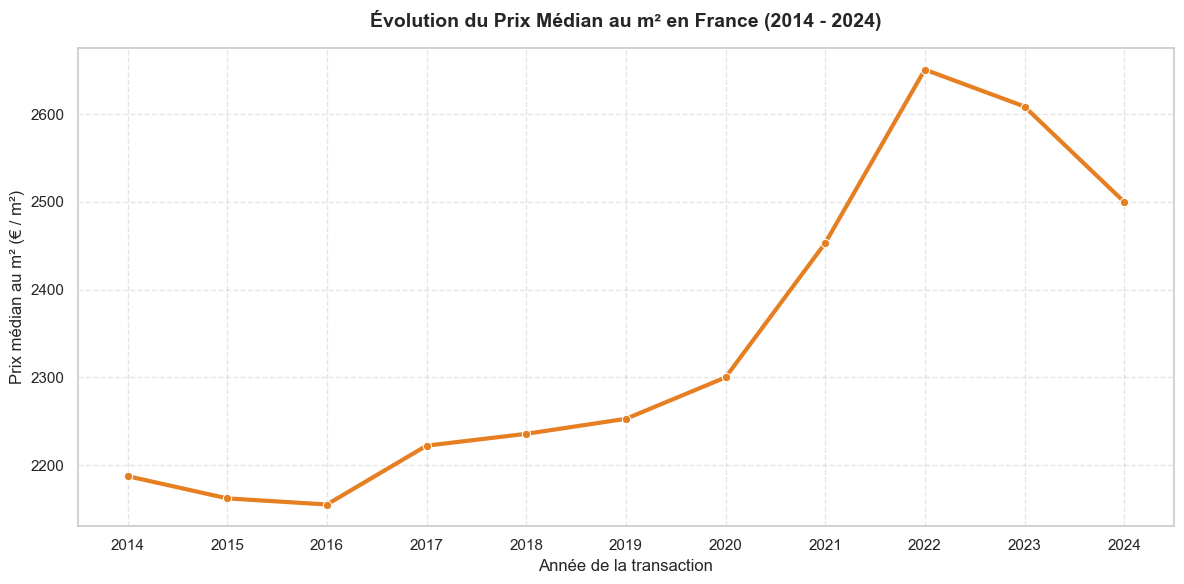

In [8]:
# 5. Évolution historique du prix au m²
with np.load(os.path.join(DATA_DIR, "transactions.npz"), allow_pickle=True) as data:
    prix = data['prix']
    surface = data['surface_habitable']
    dates = data['date_transaction']

# Construction d'un DataFrame ultra-léger avec uniquement 3 colonnes
df_evo = pd.DataFrame({'prix': prix, 'surface': surface, 'date': dates})

# Nettoyage des données aberrantes (surfaces nulles ou géantes, prix irréalistes)
df_evo = df_evo[(df_evo['surface'] >= 10) & (df_evo['surface'] <= 300)]
df_evo = df_evo[(df_evo['prix'] >= 10000) & (df_evo['prix'] <= 2000000)]

# Calcul du prix au m² et extraction de l'année
df_evo['prix_m2'] = df_evo['prix'] / df_evo['surface']
df_evo['annee'] = df_evo['date'].astype(str).str[:4]

# Calcul du prix au m² médian par an (plus robuste que la moyenne face aux extrêmes)
evolution_m2 = df_evo.groupby('annee')['prix_m2'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=evolution_m2, x='annee', y='prix_m2', marker='o', color='#E67E22', linewidth=3)
plt.title('Évolution du Prix Médian au m² en France (2014 - 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Année de la transaction', fontsize=12)
plt.ylabel('Prix médian au m² (€ / m²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Graphique 6 : Croisement Richesse des Villes vs Loyers pratiqués

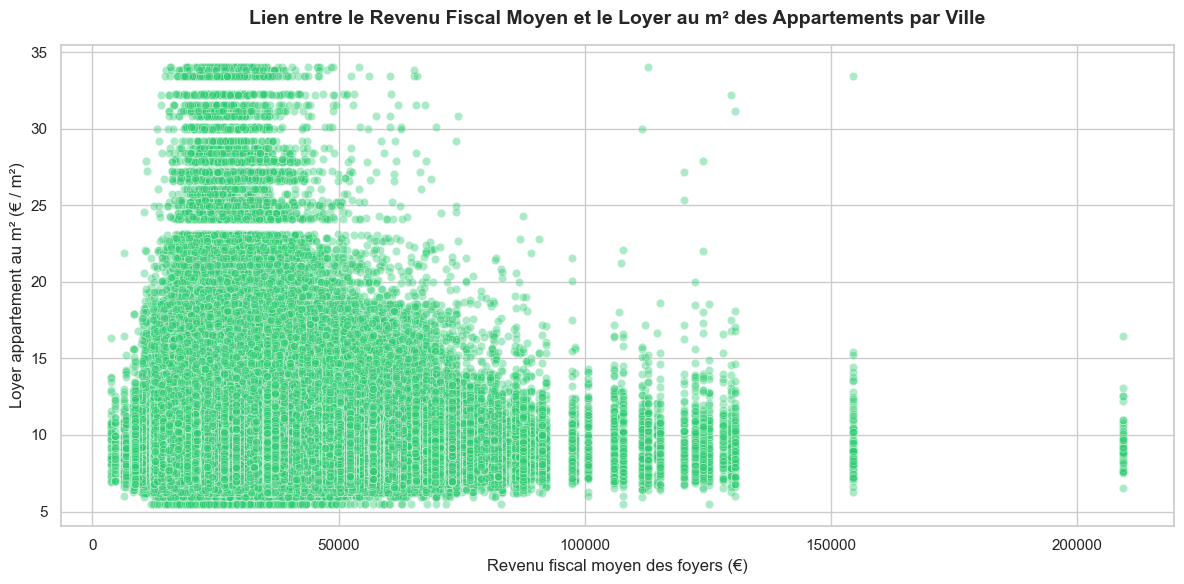

In [9]:
# 6. Corrélation Niveau de vie vs Loyers par commune
df_foyers = pd.read_csv(os.path.join(DATA_DIR, "foyers_fiscaux.csv"), sep=None, engine='python')
df_loyers = pd.read_csv(os.path.join(DATA_DIR, "loyers.csv"), sep=None, engine='python')

# Filtrage sur les données récentes pour la comparaison
df_foyers_2022 = df_foyers[df_foyers['date'] == 2022]
df_loyers_recent = df_loyers[df_loyers['date'] == df_loyers['date'].max()]

# Fusion des deux fichiers grâce à l'identifiant unique de la ville (id_ville)
df_villes_cross = pd.merge(df_foyers_2022, df_loyers_recent, on='id_ville', suffixes=('_foyer', '_loyer'))

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_villes_cross, x='revenu_fiscal_moyen', y='loyer_m2_appartement', alpha=0.4, color='#2ECC71')
plt.title('Lien entre le Revenu Fiscal Moyen et le Loyer au m² des Appartements par Ville', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Revenu fiscal moyen des foyers (€)', fontsize=12)
plt.ylabel('Loyer appartement au m² (€ / m²)', fontsize=12)
plt.tight_layout()
plt.show()

# Analyse des données erronées ou vides.

Erreur transactions.npz : 'numpy.ndarray' object has no attribute 'isna'


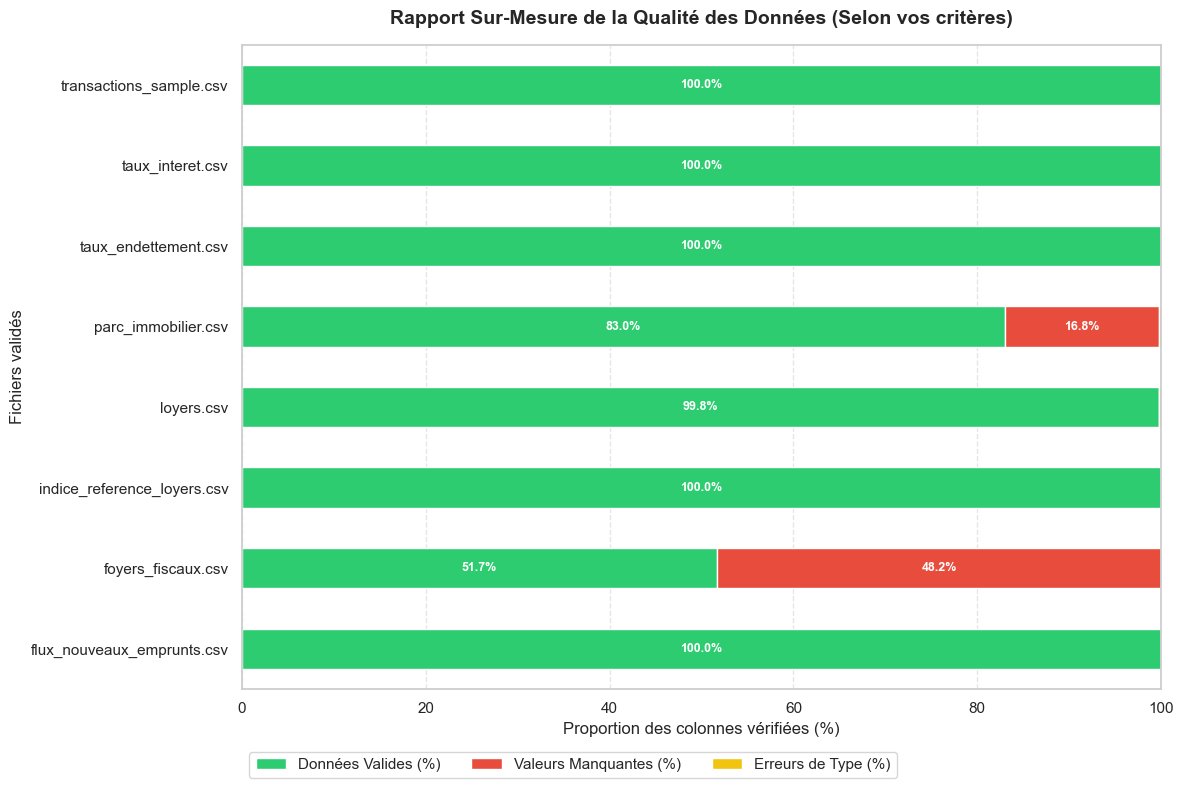

In [10]:


rapport_qualite = []

# --- 1. CONFIGURATION DE TES RÈGLES STRICTES PAR FICHIER ---
# Format attendu : { colonne: type_regle }
# Types de règles : 'date_mois' (AAAA-MM), 'date_annee' (AAAA), 'numeric' (chiffre), 'string' (lettres)
regles_fichiers = {
    "flux_nouveaux_emprunts.csv": {
        "date": "date_mois", 
        "emprunts_M€": "numeric"
    },
    "foyers_fiscaux.csv": {
        "date": "date_annee", 
        "departement": "numeric", # Tu as précisé que c'est un numéro
        "ville": "string", 
        "n_foyers_fiscaux": "numeric", 
        "revenu_fiscal_moyen": "numeric", 
        "montant_impot_moyen": "numeric",
        "n_foyers_0k_10k": "numeric", "n_foyers_10k_12k": "numeric", "n_foyers_12k_15k": "numeric",
        "n_foyers_15k_20k": "numeric", "n_foyers_20k_30k": "numeric", "n_foyers_30k_50k": "numeric",
        "n_foyers_50k_100k": "numeric", "n_foyers_100k_plus": "numeric"
    },
    "indice_reference_loyers.csv": {
        "quarter": "date_mois", # ou date complète
        "IRL": "numeric"
    },
    "loyers.csv": {
        "departement": "numeric", 
        "ville": "string", 
        "date": "date_annee", # Tu as noté : que les années
        "loyer_m2_appartement": "numeric", 
        "loyer_m2_maison": "numeric"
    },
    "parc_immobilier.csv": {
        "date": "date_annee", # Que l'année
        "departement": "numeric", 
        "ville": "string", 
        "n_logements": "numeric", 
        "n_logements_vacants": "numeric"
    },
    "taux_endettement.csv": {
        "date": "date_annee", # Que l'année
        "taux_endettement": "numeric"
    },
    "taux_interet.csv": {
        "date": "date_mois", # Année-Mois
        "taux": "numeric"
    },
    "transactions_sample.csv": {
        "id_transaction": "numeric",
        "date_transaction": "date_mois",
        "prix": "numeric",
        "departement": "numeric",
        "code_postal": "numeric",
        "type_batiment": "string",
        "n_pieces": "numeric",
        "surface_habitable": "numeric",
        "latitude": "numeric",
        "longitude": "numeric"
    }
}

# --- 2. FONCTION DE VÉRIFICATION SUR MESURE ---
for fichier, regles in regles_fichiers.items():
    try:
        # Détection automatique du séparateur français (;) ou standard (,)
        df = pd.read_csv(os.path.join(DATA_DIR, fichier), sep=None, engine='python')
        
        total_cellules = len(df) * len(regles)
        total_manquants = 0
        total_erreurs_type = 0
        
        for col, regle in regles.items():
            if col not in df.columns:
                continue
                
            series = df[col]
            
            # 1. Compter les valeurs manquantes (NaN)
            manquants_col = series.isna().sum()
            total_manquants += manquants_col
            
            # On ne teste le type que sur les données non vides
            series_clean = series.dropna()
            
            # 2. Appliquer tes règles métiers
            if regle == "numeric":
                # Si la conversion échoue, c'est que c'est du texte ou une erreur
                erreurs = len(series_clean) - pd.to_numeric(series_clean, errors='coerce').notna().sum()
                total_erreurs_type += erreurs
                
            elif regle == "string":
                # Si ça contient uniquement des chiffres alors qu'on attend des lettres
                erreurs = series_clean.astype(str).str.isnumeric().sum()
                total_erreurs_type += erreurs
                
            elif regle == "date_annee":
                # Doit être un nombre ou un texte à 4 chiffres (ex: 2018)
                erreurs = len(series_clean) - series_clean.astype(str).str.match(r'^\d{4}$').sum()
                total_erreurs_type += erreurs
                
            elif regle == "date_mois":
                # Doit commencer par AAAA-MM ou être une date convertible
                erreurs = len(series_clean) - pd.to_datetime(series_clean, errors='coerce').notna().sum()
                total_erreurs_type += erreurs

        # Calcul des pourcentages finaux
        pct_manquant = (total_manquants / total_cellules) * 100
        pct_erreur = (total_erreurs_type / total_cellules) * 100
        pct_valide = max(0, 100 - pct_manquant - pct_erreur)
        
        rapport_qualite.append({
            "Fichier": fichier,
            "Données Valides (%)": pct_valide,
            "Valeurs Manquantes (%)": pct_manquant,
            "Erreurs de Type (%)": pct_erreur
        })
        
    except Exception as e:
        print(f"Erreur d'analyse sur {fichier} : {e}")

# --- 3. TRAITEMENT DU GROS FICHIER TRANSACTIONS.NPZ ---
try:
    with np.load(os.path.join(DATA_DIR, "transactions.npz"), allow_pickle=True) as data:
        prix = data['prix']
        surface = data['surface_habitable']
        dept = data['departement']
        
        # Application de tes règles sur l'ensemble des 9M de lignes
        total_tests = len(prix) * 3
        anomalies = np.sum(prix <= 0) + np.sum(surface <= 0) + np.sum(pd.to_numeric(dept, errors='coerce').isna())
        
        pct_erreur = (anomalies / total_tests) * 100
        rapport_qualite.append({
            "Fichier": "transactions.npz",
            "Données Valides (%)": 100 - pct_erreur,
            "Valeurs Manquantes (%)": 0.0,
            "Erreurs de Type (%)": pct_erreur
        })
except Exception as e:
    print(f"Erreur transactions.npz : {e}")

# --- 4. LE GRAPHIQUE DE QUALITÉ RESPECTANT TES CRITÈRES ---
df_qualite = pd.DataFrame(rapport_qualite).set_index("Fichier")
ax = df_qualite.plot(kind='barh', stacked=True, color=['#2ecc71', '#e74c3c', '#f1c40f'], figsize=(12, 8))

plt.title("Rapport Sur-Mesure de la Qualité des Données (Selon vos critères)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Proportion des colonnes vérifiées (%)", fontsize=12)
plt.ylabel("Fichiers validés", fontsize=12)
plt.xlim(0, 100)
plt.legend(loc='lower left', bbox_to_anchor=(0, -0.15), ncol=3)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Affichage des pourcentages textuels sur le graphique
for p in ax.patches:
    width = p.get_width()
    if width > 3: # Afficher si le bloc fait plus de 3% de large
        x = p.get_x() + width / 2
        y = p.get_y() + p.get_height() / 2
        ax.annotate(f"{width:.1f}%", (x, y), ha='center', va='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()